# Employee Attrition & Workforce Analysis

### IBM SkillsBuild Data Analytics with AI Project

## Project Objective:

The objective of this project is to analyze employee attrition patterns and identify how attrition varies across different employee and workplace factors such as department, overtime, job role, job satisfaction, monthly income, and total work experience.

The analysis uses exploratory data analysis and data visualization to identify patterns in the dataset and present findings that can support workforce-related decision making.

## Dataset:

The dataset contains information about 1,470 employees across 35 columns. It includes employee demographics, department and job role information, job satisfaction, overtime, income, work experience, and other workplace-related attributes.

The target variable for this analysis is `Attrition`, which indicates whether an employee left the company (`Yes`) or stayed (`No`).

In [44]:
import pandas as pd

In [45]:
from google.colab import files

uploaded = files.upload()

Saving HR Analytics.csv to HR Analytics (1).csv


In [46]:
df = pd.read_csv("HR Analytics.csv")

In [47]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [48]:
df.shape

(1470, 35)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())


Attrition:
['Yes' 'No']

BusinessTravel:
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department:
['Sales' 'Research & Development' 'Human Resources']

EducationField:
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender:
['Female' 'Male']

JobRole:
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus:
['Single' 'Married' 'Divorced']

Over18:
['Y']

OverTime:
['Yes' 'No']


In [52]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


# Data Cleaning & Preparation:

The dataset was checked for missing values, duplicate records, inconsistent categorical values, and constant columns.

No missing values or duplicate records were found. The categorical values were also reviewed for consistency.

Three columns — `EmployeeCount`, `Over18`, and `StandardHours` — contain only one unique value and therefore do not provide variation for the analysis. These columns were not used in the analytical comparisons.

The original dataset was kept unchanged, and additional grouping columns were created only when required for analysis.

In [53]:
# Check for missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [54]:
# Check for constant columns
constant_columns = [col for col in df.columns if df[col].nunique() == 1]

constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

In [55]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

**# Overall Employee Attrition**

In [56]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [57]:
df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


**Finding:-**
**Employee** **attrition** in the dataset is **16.12%**, with **237 out of 1,470** employees having **left** the company.

**# Department wise Attrition**

In [58]:
pd.crosstab(df['Department'], df['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [59]:
pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


**Finding:-**
Sales had the highest attrition rate at 20.63%, followed by Human Resources at 19.05%, while Research & Development had the lowest attrition rate at 13.84%.

**# Overtime vs. Attrition**

In [60]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [61]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


**Finding:-**
Employees who worked overtime had a higher attrition rate (30.53%) compared with employees who did not work overtime (10.44%) in this dataset.

**# Job Role vs. Attrition**

In [62]:
pd.crosstab(df['JobRole'], df['Attrition'])

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


In [63]:
pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


**Finding:-**
Sales Representatives had the highest attrition rate at 39.76%, while Research Directors had the lowest at 2.50% in this dataset.

**# Job Satisfaction vs. Attrition**

In [64]:
pd.crosstab(df['JobSatisfaction'], df['Attrition'])

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [65]:
pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index') * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


**Finding:-**
Employees with Job Satisfaction level 1 had the highest attrition rate at 22.84%, while those with level 4 had the lowest at 11.33% in this dataset.

**# Monthly Income vs. Attrition**

In [66]:
df['IncomeGroup'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [67]:
pd.crosstab(df['IncomeGroup'], df['Attrition'])

Attrition,No,Yes
IncomeGroup,,
Low,261,108
Medium,314,52
High,328,39
Very High,330,38


In [68]:
pd.crosstab(
    df['IncomeGroup'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
IncomeGroup,,
Low,70.731707,29.268293
Medium,85.792350,14.207650
High,89.373297,10.626703
Very High,89.673913,10.326087


**Finding:-**
The Low income group had the highest attrition rate at 29.27%, while the Very High income group had the lowest at 10.33% in this dataset.

**# Total Working Years vs. Attrition**

In [69]:
df['ExperienceGroup'] = pd.cut(
    df['TotalWorkingYears'],
    bins=[-1, 5, 10, 20, 40],
    labels=['0–5 years', '6–10 years', '11–20 years', '21+ years']
)

In [70]:
pd.crosstab(df['ExperienceGroup'], df['Attrition'])

Attrition,No,Yes
ExperienceGroup,,
0–5 years,225,91
6–10 years,516,91
11–20 years,301,39
21+ years,191,16


In [71]:
pd.crosstab(
    df['ExperienceGroup'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
ExperienceGroup,,
0–5 years,71.202532,28.797468
6–10 years,85.008237,14.991763
11–20 years,88.529412,11.470588
21+ years,92.270531,7.729469


**Finding:-**
Employees with 0–5 years of total working experience had the highest attrition rate at 28.80%, while employees with 21+ years of experience had the lowest at 7.73% in this dataset

**# Business Travel vs. Attrition**

In [72]:
pd.crosstab(df['BusinessTravel'], df['Attrition'])

Attrition,No,Yes
BusinessTravel,,
Non-Travel,138,12
Travel_Frequently,208,69
Travel_Rarely,887,156


In [73]:
pd.crosstab(
    df['BusinessTravel'],
    df['Attrition'],
    normalize='index'
) * 100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


**Finding:-**
Employees in the Travel_Frequently group had the highest attrition rate at 24.91%, while the Non-Travel group had the lowest at 8.00% in this dataset.

# Data Visualizations

**# Overall Employee Attrition**

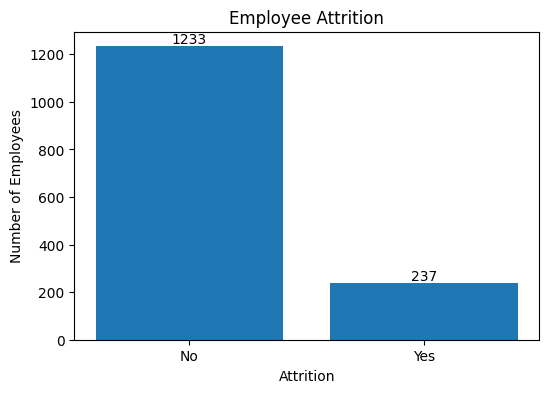

In [74]:
import matplotlib.pyplot as plt

attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6, 4))
bars = plt.bar(attrition_counts.index, attrition_counts.values)

plt.title('Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

# Add values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

plt.show()

**Insight:-**
Out of 1,470 employees, 237 employees had left the company, resulting in an overall attrition rate of 16.12%.

**# Attrition Rate by Department**

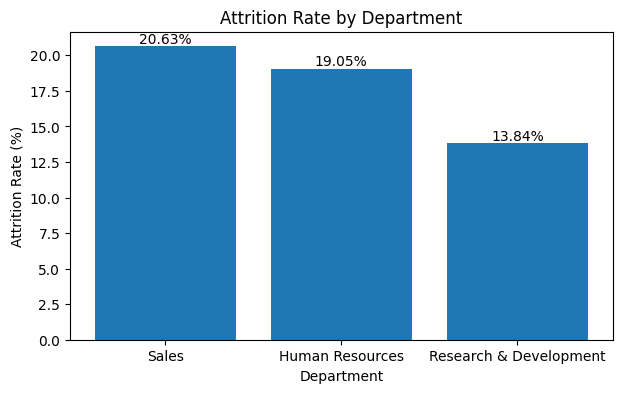

In [75]:
import matplotlib.pyplot as plt

department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

# Get attrition rate (Yes) and sort it
department_rates = department_attrition['Yes'].sort_values(ascending=False)

plt.figure(figsize=(7, 4))
bars = plt.bar(department_rates.index, department_rates.values)

plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

# Add percentage values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

**Insight:-**
Sales and Human Resources showed higher attrition rates than Research & Development, indicating that attrition was not evenly distributed across departments in this dataset.

**# Attrition Rate by Overtime**

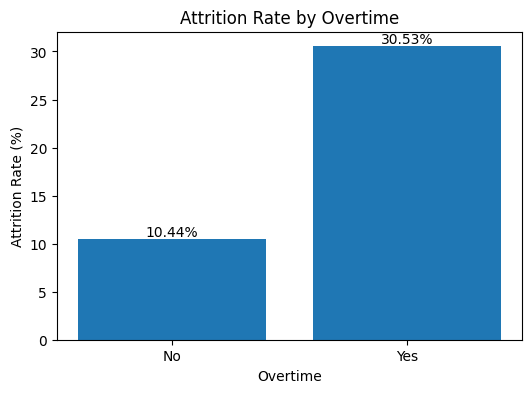

In [76]:
import matplotlib.pyplot as plt

overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

overtime_rates = overtime_attrition['Yes']

plt.figure(figsize=(6, 4))
bars = plt.bar(overtime_rates.index, overtime_rates.values)

plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')

# Add percentage values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

**Insight:-**
Employees who worked overtime had a higher attrition rate (30.53%) compared with employees who did not work overtime (10.44%) in this dataset.

**# Attrition Rate by Job Role**

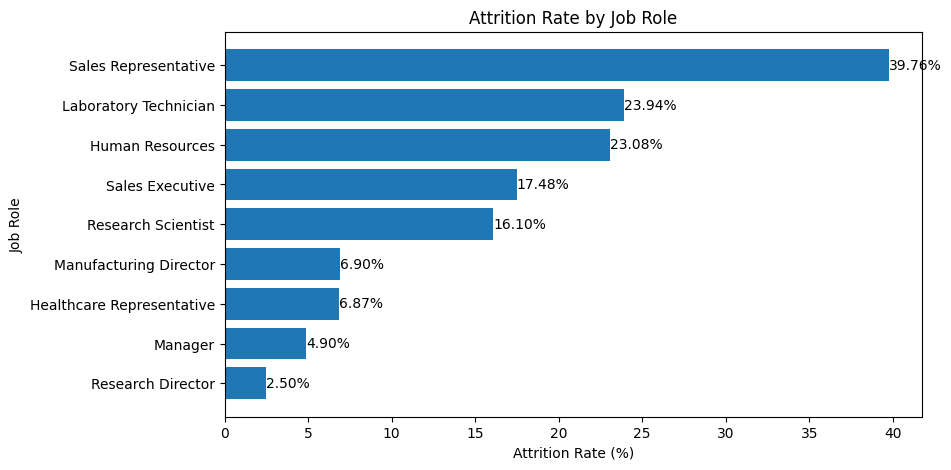

In [77]:
import matplotlib.pyplot as plt

jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

jobrole_rates = jobrole_attrition['Yes'].sort_values(ascending=True)

plt.figure(figsize=(9, 5))

bars = plt.barh(jobrole_rates.index, jobrole_rates.values)

plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')

# Add percentage values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}%',
        ha='left',
        va='center'
    )

plt.show()

**Insight:-**
Attrition rates varied across job roles in this dataset, with Sales Representatives showing the highest rate at 39.76% and Research Directors showing the lowest at 2.50%.

**# Attrition Rate by Monthly Income**

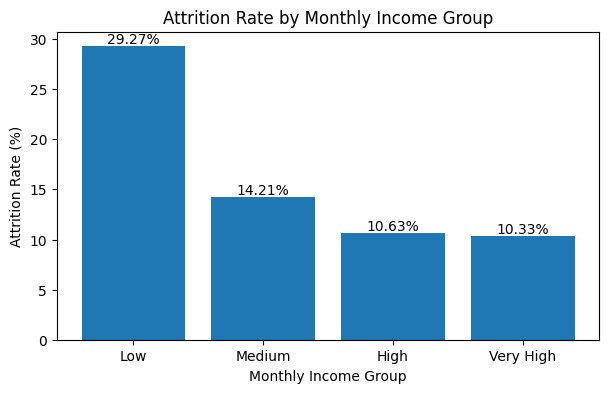

In [78]:
import matplotlib.pyplot as plt

income_attrition = pd.crosstab(
    df['IncomeGroup'],
    df['Attrition'],
    normalize='index'
) * 100

income_rates = income_attrition['Yes']

plt.figure(figsize=(7, 4))

bars = plt.bar(income_rates.index, income_rates.values)

plt.title('Attrition Rate by Monthly Income Group')
plt.xlabel('Monthly Income Group')
plt.ylabel('Attrition Rate (%)')

# Add percentage values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

**Insight:-**
The Low income group had the highest attrition rate at 29.27%, while the Very High income group had the lowest at 10.33% in this dataset.

**# Attrition Rate by Experience**

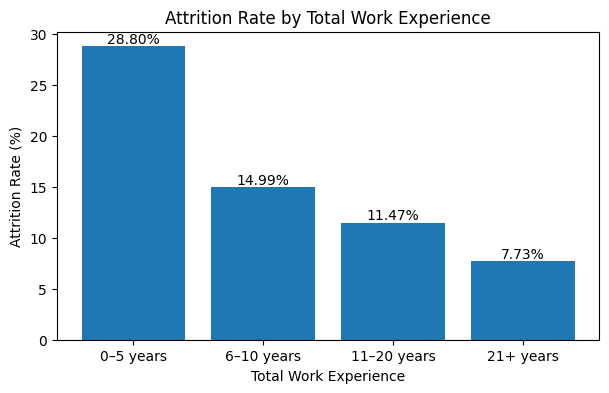

In [79]:
import matplotlib.pyplot as plt

experience_attrition = pd.crosstab(
    df['ExperienceGroup'],
    df['Attrition'],
    normalize='index'
) * 100

experience_rates = experience_attrition['Yes']

plt.figure(figsize=(7, 4))

bars = plt.bar(experience_rates.index, experience_rates.values)

plt.title('Attrition Rate by Total Work Experience')
plt.xlabel('Total Work Experience')
plt.ylabel('Attrition Rate (%)')

# Add percentage values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

**Insight:-**
Employees with 0-5 years of total work experience had the highest attrition rate at 28.80%, while employees with 21+ years of experience had the lowest at 7.73% in this dataset.

# Conclusion

This project analyzed employee attrition patterns across different employee and workplace factors using exploratory data analysis and data visualization.

The dataset has an overall attrition rate of 16.12%. Higher attrition rates were observed among employees who worked overtime, employees in the Sales department, Sales Representatives, employees in the Low income group, and employees with 0–5 years of total work experience.

Attrition also varied across job satisfaction levels and business travel categories. These patterns show that employee attrition was not evenly distributed across the different groups analyzed.

The findings in this project describe patterns and associations present in the dataset. They do not establish that any individual factor directly causes employee attrition.

## Key Takeaways

- Overall employee attrition rate was **16.12%**.
- Employees working overtime had an attrition rate of **30.53%**, compared with **10.44%** for employees who did not work overtime.
- The **Sales** department had the highest attrition rate among the three departments at **20.63%**.
- **Sales Representatives** had the highest attrition rate among the analyzed job roles at **39.76%**.
- The **Low income** group had an attrition rate of **29.27%**.
- Employees with **0–5 years** of total work experience had an attrition rate of **28.80%**.